In [1]:
# CELL 1 — IMPORTS & CONFIGURATION
# ============================================

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    train_test_split,
    learning_curve,
    validation_curve
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

os.makedirs("output", exist_ok=True)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
# CELL 2 — DATASET GENERATION
# ============================================

def generate_uci_bonn(
    n_healthy=300,
    n_seizure=75,
    signal_length=1024
):

    healthy = np.zeros((n_healthy, signal_length))

    for i in range(n_healthy):
        t = np.linspace(0, 10, signal_length)

        healthy[i] = (
            0.5 * np.sin(2 * np.pi * 10 * t)
            + 0.2 * np.sin(2 * np.pi * 20 * t)
            + np.random.normal(0, 0.1, signal_length)
        )

    seizure = np.zeros((n_seizure, signal_length))

    for i in range(n_seizure):
        t = np.linspace(0, 10, signal_length)

        spike = np.zeros(signal_length)

        for j in range(0, signal_length, 40):
            if j + 10 < signal_length:
                spike[j:j+10] = 2 * np.exp(-np.linspace(0, 2, 10))

        seizure[i] = (
            spike
            + 0.8 * np.sin(2 * np.pi * 40 * t)
            + np.random.normal(0, 0.15, signal_length)
        )

    X = np.vstack([healthy, seizure])
    y = np.hstack([np.zeros(n_healthy), np.ones(n_seizure)])

    idx = np.random.permutation(len(y))

    return X[idx], y[idx].astype(int)


In [3]:
# CELL 3 — FEATURE EXTRACTION
# ============================================

class EEGFeatureExtractor(BaseEstimator, TransformerMixin):

    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):

        features = []

        for signal in X:

            feat = []

            feat.append(np.mean(signal))
            feat.append(np.std(signal))
            feat.append(np.min(signal))
            feat.append(np.max(signal))
            feat.append(np.var(signal))
            feat.append(np.mean(signal**2))

            d1 = np.diff(signal)

            activity = np.var(signal)
            mobility = np.sqrt(np.var(d1) / (activity + 1e-10))

            feat.append(activity)
            feat.append(mobility)

            fft = np.abs(np.fft.fft(signal))[:len(signal)//2]

            feat.append(np.mean(fft))
            feat.append(np.std(fft))

            features.append(feat)

        return np.array(features)


In [4]:
# CELL 4 — PIPELINES
# ============================================

class PipelineA:

    def build(self):

        return Pipeline([
            ("extractor", EEGFeatureExtractor()),
            ("scaler", StandardScaler()),
            ("selector", SelectKBest(f_classif, k=8))
        ])


class PipelineB:

    def build(self):

        return Pipeline([
            ("extractor", EEGFeatureExtractor()),
            ("scaler", RobustScaler()),
            ("pca", PCA(n_components=0.95))
        ])


class PipelineC:

    def build(self):

        return Pipeline([
            ("extractor", EEGFeatureExtractor()),
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=0.90))
        ])


In [5]:
# CELL 5 — EVALUATION FUNCTION
# ============================================

def evaluate_model(model, X_train, X_test, y_train, y_test):

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob),
        "PR_AUC": average_precision_score(y_test, y_prob)
    }


In [6]:
# CELL 6 — DATASET CREATION
# ============================================

X, y = generate_uci_bonn()

print("Dataset Shape:", X.shape)
print("Labels Shape:", y.shape)

print("\nClass Distribution:")
print(Counter(y))


Dataset Shape: (375, 1024)
Labels Shape: (375,)

Class Distribution:
Counter({np.int64(0): 300, np.int64(1): 75})


In [7]:
# CELL 7 — TRAIN TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)


Train Shape: (300, 1024)
Test Shape: (75, 1024)


In [8]:
# CELL 8 — BASELINE MODEL
# ============================================

pipe = PipelineA().build()

X_train_transformed = pipe.fit_transform(X_train, y_train)
X_test_transformed = pipe.transform(X_test)

model = LogisticRegression(
    penalty="l2",
    C=1.0,
    max_iter=1000,
    random_state=RANDOM_STATE
)

results = evaluate_model(
    model,
    X_train_transformed,
    X_test_transformed,
    y_train,
    y_test
)

print("\nBaseline Results:\n")

for k, v in results.items():
    print(f"{k}: {v:.4f}")



Baseline Results:

Accuracy: 1.0000
F1: 1.0000
Precision: 1.0000
Recall: 1.0000
ROC_AUC: 1.0000
PR_AUC: 1.0000


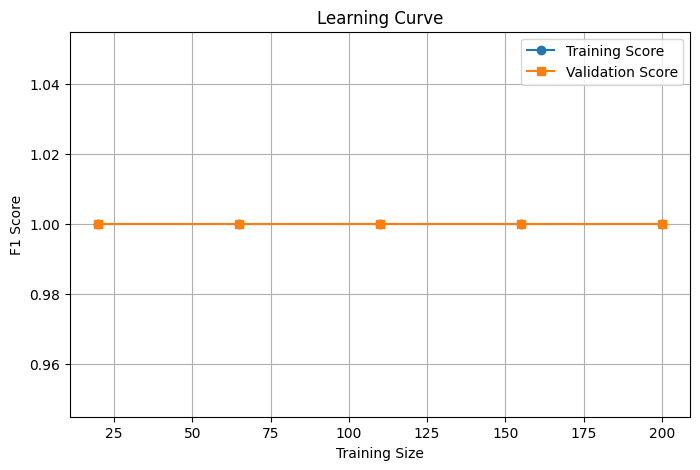

In [9]:
# CELL 9 — LEARNING CURVE
# ============================================

train_sizes, train_scores, val_scores = learning_curve(
    model,
    X_train_transformed,
    y_train,
    cv=3,
    scoring="f1",
    train_sizes=np.linspace(0.1, 1.0, 5)
)

plt.figure(figsize=(8,5))

plt.plot(
    train_sizes,
    train_scores.mean(axis=1),
    "o-",
    label="Training Score"
)

plt.plot(
    train_sizes,
    val_scores.mean(axis=1),
    "s-",
    label="Validation Score"
)

plt.xlabel("Training Size")
plt.ylabel("F1 Score")
plt.title("Learning Curve")
plt.legend()
plt.grid(True)

plt.show()


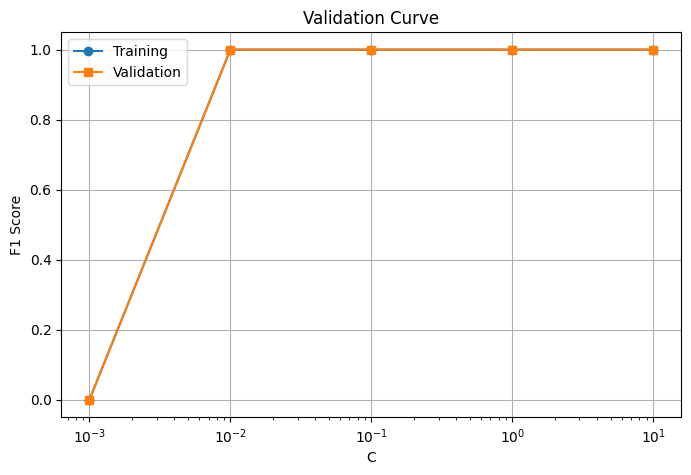

In [10]:
# CELL 10 — VALIDATION CURVE
# ============================================

C_range = np.logspace(-3, 1, 5)

train_scores, val_scores = validation_curve(
    LogisticRegression(
        penalty="l2",
        max_iter=1000,
        random_state=RANDOM_STATE
    ),
    X_train_transformed,
    y_train,
    param_name="C",
    param_range=C_range,
    cv=3,
    scoring="f1"
)

plt.figure(figsize=(8,5))

plt.semilogx(
    C_range,
    train_scores.mean(axis=1),
    "o-",
    label="Training"
)

plt.semilogx(
    C_range,
    val_scores.mean(axis=1),
    "s-",
    label="Validation"
)

plt.xlabel("C")
plt.ylabel("F1 Score")
plt.title("Validation Curve")
plt.legend()
plt.grid(True)

plt.show()


In [11]:
# CELL 11 — REGULARIZATION STUDY
# ============================================

results_list = []

for penalty in ["l1", "l2"]:

    for C in [0.01, 0.1, 1, 10]:

        solver = "liblinear" if penalty == "l1" else "lbfgs"

        model = LogisticRegression(
            penalty=penalty,
            C=C,
            solver=solver,
            max_iter=1000,
            random_state=RANDOM_STATE
        )

        res = evaluate_model(
            model,
            X_train_transformed,
            X_test_transformed,
            y_train,
            y_test
        )

        res["Penalty"] = penalty
        res["C"] = C

        results_list.append(res)

df = pd.DataFrame(results_list)

df


,Accuracy,F1,Precision,Recall,ROC_AUC,PR_AUC,Penalty,C
0,1.0,1.0,1.0,1.0,1.0,1.0,l1,0.01
1,1.0,1.0,1.0,1.0,1.0,1.0,l1,0.10
2,1.0,1.0,1.0,1.0,1.0,1.0,l1,1.00
3,1.0,1.0,1.0,1.0,1.0,1.0,l1,10.00
4,1.0,1.0,1.0,1.0,1.0,1.0,l2,0.01
5,1.0,1.0,1.0,1.0,1.0,1.0,l2,0.10
6,1.0,1.0,1.0,1.0,1.0,1.0,l2,1.00
7,1.0,1.0,1.0,1.0,1.0,1.0,l2,10.00


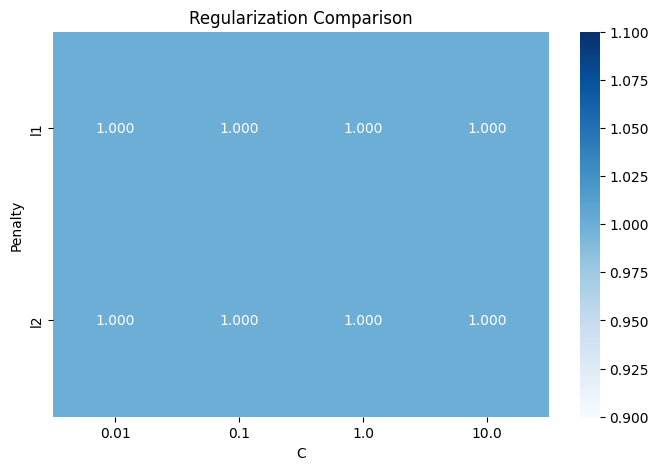

In [12]:
# CELL 12 — HEATMAP
# ============================================

pivot = df.pivot_table(
    values="F1",
    index="Penalty",
    columns="C"
)

plt.figure(figsize=(8,5))

sns.heatmap(
    pivot,
    annot=True,
    cmap="Blues",
    fmt=".3f"
)

plt.title("Regularization Comparison")
plt.show()


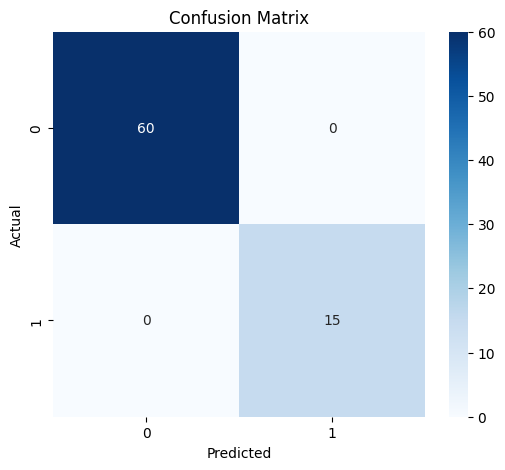

In [13]:
# CELL 13 — CONFUSION MATRIX
# ============================================

y_pred = model.predict(X_test_transformed)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()


In [14]:
# CELL 14 — SAVE RESULTS
# ============================================

df.to_csv("output/results.csv", index=False)

print("Results Saved Successfully")


Results Saved Successfully
